In [18]:
#Import#

from cellpose import models, core, io, plot
from cellpose import train
from cellpose import metrics
import pickle, numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import imageio.v2 as imageio
import os
import skimage.filters
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from skimage import exposure
from skimage.measure import regionprops
from skimage.segmentation import watershed
from skimage.segmentation import mark_boundaries
from skimage import img_as_float
from skimage.filters import sobel
from skimage.feature import blob_dog
from skimage import data, color, filters, segmentation, measure, morphology
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist
from scipy.spatial import distance_matrix
from scipy.ndimage import generate_binary_structure, binary_dilation
from scipy.spatial import Delaunay
from scipy.stats import qmc
import pandas as pd
from glob import glob
import cv2
import re
from collections import Counter


import time

In [2]:
#Data input from the User

folder_path = r'Y:\Group Members\Valentin Aubry\01_Data\Data_Andreas_single'  # The r in r'Example\Pathway' is very important to get the raw input


# Check if the folder is empty or even exists
if os.path.isdir(folder_path) == True:
    print("Folder Path exists")

    # Getting the list of directories
    dir = os.listdir(folder_path)
    
    # Checking if the list is empty or not
    if len(dir) == 0:
        print("Empty directory")
    else:
        print("Not empty directory")
else:
    print("Folder path not found")

Folder Path exists
Not empty directory


In [3]:
# Data Loading


# High Throughput Data Loading
Cy5_data = glob(os.path.join(folder_path, '*Cy5 SEM.tif'))
DAPI_data = glob(os.path.join(folder_path, '*DAPI SEM.tif'))
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))
FITC_data = glob(os.path.join(folder_path, '*FITC SEM.tif'))
TRITC_data = glob(os.path.join(folder_path, '*TRITC SEM.tif'))


# Sorting the data in case it isn't yet
Cy5_data.sort()
DAPI_data.sort()
DAPI_mask_data.sort()
FITC_data.sort()
TRITC_data.sort()


# Displaying all the data that was loaded
for i in range (len(DAPI_data)):
    print(os.path.basename(Cy5_data[i]))
    print(os.path.basename(DAPI_data[i]))
    print(os.path.basename(DAPI_mask_data[i]))
    print(os.path.basename(FITC_data[i]))
    print(os.path.basename(TRITC_data[i]))





ATR2_24h--W00044--P00021--Z00000--T00000--Cy5 SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM_seg.npy
ATR2_24h--W00044--P00021--Z00000--T00000--FITC SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--TRITC SEM.tif


In [27]:
# Loading Functions

# Function to check if a potential foci is X-times brighter than the immediate Background (preventing false positives)
def local_contrast(image, coordinates, bright_percentage, contrast_threshold=2.5):
    """
    Filter detected foci by comparing their intensity to local background.
    
    This function confirms foci as true positives only if they are significantly
    brighter than their immediate surroundings, reducing false positive detections
    from background noise or imaging artifacts.
    
    Parameters:
    -----------
    image : numpy.ndarray
        2D array of the fluorescence image (grayscale) where foci are detected.
        Typically a single channel (e.g., TRITC, FITC) image.
    
    coordinates : numpy.ndarray
        Array of shape (N, 2) containing (y, x) coordinates of potential foci
        detected by peak_local_max or similar detection methods.
    
    bright_percentage : int or float
        Percentile (0-100) used to define local background brightness.
        For example:
        - 50 compares to median brightness around the focus
        - 25 compares to dimmer regions (more stringent filtering)
        - 75 compares to brighter regions (less stringent filtering)
    
    contrast_threshold : float, optional (default=2.5)
        Minimum contrast ratio between focus and local background.
        Focus intensity must be > (local_background * contrast_threshold).
        Higher values = more stringent filtering (fewer false positives).
        Typical values: 1.5-3.0
    
    Returns:
    --------
    numpy.ndarray
        Array of shape (M, 2) containing confirmed foci coordinates where M <= N.
        Returns empty array of shape (0, 2) if no foci pass the contrast filter.
    
    Notes:
    ------
    - Uses an 11x11 pixel square (±5 pixels) around each potential focus
    - Edge cases are handled by clamping to image boundaries
    - Empty return is shaped (0, 2) for compatibility with downstream processing
    """
    confirmed_coords = []  #Empty array to store the filtered coordinates in later
    for i in coordinates:
        y, x = i   # Get the coordinates for each foci 
        y_min, y_max = max(0, y-6), min(image.shape[0], y+7)  #setting boudaries from y-5 to y+5(Y+6 gets excluded as upper border)
        x_min, x_max = max(0, x-6), min(image.shape[1], x+7)
        square = image[y_min:y_max, x_min:x_max]  #creating a square with the defined boudaries

        potential_foci = image[y, x]
        local_background = np.percentile(square, bright_percentage)  # Selects a pixel with the brightness in the defined percentage for comparison

        if potential_foci > local_background * contrast_threshold:  # If the potential foci is X-times brighter than the selected background, the foci is confirmed
            confirmed_coords.append(i)
            
    # returns the confirmed foci coordinates or if there are none creates an empty array to not crash the display below
    return np.array(confirmed_coords) if confirmed_coords else np.array([]).reshape(0, 2)





def save_dataframe_to_csv(df, folder_path, base_name, data_type):
    """
    Save a DataFrame to CSV with Excel-compatible formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to save
    folder_path : str
        Directory where file will be saved
    base_name : str
        Base filename (without extension)
    data_type : str
        Type of data being saved (e.g., 'foci', 'nucleus', 'cytoplasm')
    """
    filename = f"{folder_path}/{base_name}--{data_type}_DF_SEM.csv"
    
    # Write sep=, line for Excel compatibility
    with open(filename, 'w') as f:
        f.write('sep=,\n')
    
    # Write data with header
    df.to_csv(filename, mode='a', header=True, index=False)


def farthest_point_sampling(points, n_samples):
    """
    Selects a subset of points that are maximally spread apart 
    (farthest-point or maximin sampling).

    Parameters
    ----------
    points : ndarray of shape (N, D)
        The full set of candidate points (e.g., Sobol samples inside a hull).
    n_samples : int
        The number of points to select.

    Returns
    -------
    selected_points : ndarray of shape (n_samples, D)
        The subset of points that are as far apart as possible.

    Algorithm
    ---------
    1. Pick one random starting point.
    2. Compute distances from all points to this selected point.
    3. Iteratively:
       - Choose the point with the largest distance to the nearest selected point.
       - Add it to the selected set.
       - Update distances so that each point stores its distance to the nearest selected point.
    4. Continue until n_samples points are selected.

    This greedy algorithm ensures each new point lies in the largest remaining empty region.
    It produces a very even spatial coverage, similar to Poisson-disk sampling.
    """

    n = len(points)
    if n_samples > n:
        raise ValueError("n_samples cannot exceed number of available points")

    # Picking a random starting point
    selected_idx = [np.random.randint(0, n)]

    # Computing distances from all points to the first selected point
    # Each element in 'dists' stores the distance to the *nearest selected* point so far
    dists = np.linalg.norm(points - points[selected_idx[0]], axis=1)

    # Iteratively adding points farthest from the selected set
    for _ in range(1, n_samples):
        # Find the index of the point that is farthest from all selected points
        next_idx = np.argmax(dists)
        selected_idx.append(next_idx)

        # Update distances: for every point, 
        # store the distance to the nearest selected point (so far)
        new_dists = np.linalg.norm(points - points[next_idx], axis=1)
        dists = np.minimum(dists, new_dists)

    # Returning the selected subset
    return points[selected_idx]

In [29]:
#timer to measure how long it takes
start_time = time.time()

#-----------Delaunay + Sobel-------------#

#load the convex hull and the bounding box parameters to iterate through the parameters
with open(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\valid_parameter_hull.pkl", "rb") as f:
    delaunay = pickle.load(f)
param_bounds = dict(np.load(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\parameter_bounds.npz"))

#Define function to get an ndarray with the shape of the hull saved (-1 is outside of the hull shape)
def in_hull(p):
    return delaunay.find_simplex(p) >= 0


# Generate stratified parameter samples
n_parameter_samples = 256  # Target valid samples
n_sobol = 2048*2*2               # oversampling to ensure we have enough valid ones (increase if needed)

print(f"Generating {n_sobol} Sobol samples...")
sampler = qmc.Sobol(d=3, scramble=True)
unit_samples = sampler.random(n=n_sobol)

# Scale Sobol samples from [0,1]³ to your parameter bounds (Bounding box of the selected convex hull)
scaled_samples = qmc.scale(
    unit_samples,
    l_bounds=[
        param_bounds["bright_pct"][0],
        param_bounds["contrast_thresh"][0],
        param_bounds["percentile_val"][0],
    ],
    u_bounds=[
        param_bounds["bright_pct"][1],
        param_bounds["contrast_thresh"][1],
        param_bounds["percentile_val"][1],
    ],
)

# Filter all points inside the Delaunay hull
inside_mask = in_hull(scaled_samples)
valid_points = scaled_samples[inside_mask]

valid_param_samples = farthest_point_sampling(valid_points, n_samples=n_parameter_samples)
#To be able to calculate the probability of each foci being detected
total_iterations = len(valid_param_samples)

print(f"✓ Generated {len(valid_param_samples)} valid parameter combinations")
print(f"  Bright %: {valid_param_samples[:,0].min():.1f}-{valid_param_samples[:,0].max():.1f}")
print(f"  Contrast: {valid_param_samples[:,1].min():.2f}-{valid_param_samples[:,1].max():.2f}")
print(f"  Percentile: {valid_param_samples[:,2].min():.1f}-{valid_param_samples[:,2].max():.1f}")


#-------------------------------------#

# CREATE LIST TO ACCUMULATE ALL FOCI DATA FOR ALL IMAGES
all_foci_data = []

# List to add all Data pertaining the Nuclei
all_nuclei_data = []

# To store all the results from the parameter iterations
parameter_results = []





#High Throughput Data Loading Loop
for i in range (len(DAPI_data)):
#for i in range (1,4):
    #Loading the picture on i position from each channel
    Cy5_pic = imageio.imread(Cy5_data[i])
    DAPI_pic = imageio.imread(DAPI_data[i])
    DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)
    FITC_pic = imageio.imread(FITC_data[i])
    TRITC_pic = imageio.imread(TRITC_data[i])

    # Extract the name of the picture that will be analyzed to later be able to save it accordingly
    base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')

    # Extract the well number
    # searching the base name for the string --W and then all the numbers 0-9 with \d and the + to look for one or more of the numbers 0-9 with he () it saves them
    well_match = re.search(r'--W(\d+)', base_name)
    # group(1) gets just the numbers, group(0) would be with the --W as a prefix. If no numbers are found print of Error
    well_number = well_match.group(1) if well_match else print("Well Number not found") 

    # Extract the Posiiton number --> same principle like extraction of well number extraction
    position_match = re.search(r'--P(\d+)', base_name)
    position_number = position_match.group(1) if well_match else print("Position Number not found") 
    

    # Converting the TRITC picture to float to make sure that all the pixel values are compatible with eachother
    TRITC_pic = img_as_float(TRITC_pic)

    # Extract the actual mask array
    masks = DAPI_mask_pic  # This contains the segmented regions

    ######################DATA ANALYSIS#############################
    testrange = [42,100]

    
    # Function to go through every cell individually that cellpose recognized
    #for j in range (1,len(np.unique(masks))): # Needs to start at 1 to skip the background
    for j in range (100,101):
    #for j in testrange:
        
        # Defining which nucleus from the Segmentation Mask is isolated
        cellnumber = j
        masks_reduced = (masks == cellnumber)  
    
        # Overlaying DAPI mask to TRITC
        masked_TRITC = np.ma.masked_where(masks_reduced == 0, masks_reduced)  
    
        # Applying the mask to the TRITC picture by setting the background to 0 (black)
        isolated_TRITC = TRITC_pic.copy()  # copying the original picture so that it doesn't get changed
        isolated_TRITC[masks_reduced==False] = 0  # assign the pixels from the TRITC picture copy the value 0 (black), where the mask has the value false (background)
        
        # Applying a difference of gaussian filter on the picture --> enhances peaks and smooths out background
        filtered_TRITC = skimage.filters.difference_of_gaussians(isolated_TRITC, low_sigma=1, high_sigma=2, mode='nearest', cval=0, channel_axis=None, truncate=4.0)
        filtered_TRITC = np.clip(filtered_TRITC, 0, None)  # This just ensures that the pixels don't have negative value (0 = Black)

        # Changing the pixel brightness values of the filtered picture so that they are in the same range like the unfiltered one 
        filtered_TRITC = exposure.rescale_intensity(filtered_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))

#------------Iteration of the minimal foci brightness/ Background Brightness/ Contrast Threshold---------------#
        
        foci_counts = []
        all_detected_foci = []


        for param_idx, params in enumerate(valid_param_samples):
            bright_pct, contrast_thresh, percentile_val = params
         
            # Pixels need to be at least as bright as the defined fraction of the brightes pixel in the picture
            min_brightness = np.percentile(TRITC_pic[TRITC_pic > 0], percentile_val)
       
     
            # Detecting the coordinates of the ptential foci in the unfiltered picture
            coordinates_filtered = peak_local_max(
                filtered_TRITC, 
                min_distance=2,        # This is just the minimal distance of how close two foci can be detected next to eachother
                threshold_abs=min_brightness       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
            )
            
            # Detecting the coordinates of the potential foci in the filtered picture
            coordinates_unfiltered = peak_local_max(
                isolated_TRITC, 
                min_distance=2,        # This is just the minimal distance of how close two foci can be detected next to eachother
                threshold_abs=min_brightness       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
            )
        
            
            # Checking if the detected foci are brighter than their immediate background
            coords_unfilt_test = local_contrast(isolated_TRITC, coordinates_unfiltered, bright_pct, contrast_threshold=contrast_thresh)
            coords_filt_test = local_contrast(filtered_TRITC, coordinates_filtered, bright_pct, contrast_threshold=contrast_thresh)
    
            # Confirm foci detected in the undfiltered picture if they were also detected in the filtered one (within tolerance distance)
            distances = cdist(coords_unfilt_test, coords_filt_test)  # calculate the distance between filtered foci and unfiltered foci
            tolerance = 2  # pixels of how far apart the foci maximally can be on both pictures to be confirmed
    
            if coords_unfilt_test.size > 0 and coords_filt_test.size > 0:
                # Keep foci from unfiltered that have a match in filtered
                coordinates = coords_unfilt_test[np.min(distances, axis=1) <= tolerance]  # np.min: find minimal distance between nearest foci, 
                #<=tolerance: creates a boolean array with true for each unfiltered foci with a filtered one within tolerance, 
                #coordinates_unfiltered[]: keeps only foci that are True
            else:
                coordinates = np.array([]).reshape(0, 2)  #generating an epmty array, so that the visualization down below doesn't get an error if no foci was detected

            # Save all the foci counts for the nuclei data
            foci_counts.append(len(coordinates))
            # Saving all the coordinates of the individual foci in a list to later analyze and save in teh foci data
            for coord in coordinates:
                all_detected_foci.append(tuple(coord))


            parameter_results.append({
                "cell_num": cellnumber,
                "bright_pct": bright_pct,
                "contrast_thresh": contrast_thresh,
                "percentile_val": percentile_val,
                "foci_count": len(coordinates)
            })

        parameter_results_df = pd.DataFrame(parameter_results)
        # From all the iterations calculating the mean and the standard deviation
        mean_foci = np.mean(foci_counts)
        std_foci = np.std(foci_counts)
        min_foci = min(foci_counts)
        max_foci = max(foci_counts)

        
        print(f"Mean foci: {mean_foci:.2f}")
        print(f"Standard deviation: {std_foci:.2f}")


        # Count how many times each focus was detected (detection probability)
        foci_detection_count = Counter(all_detected_foci) # Example focus has been detected 85 times in X1,Y1: {(X1,Y1): 85, (X2,Y2): 30, ...}

        # Get the iteration with maximum foci
        max_foci_count = max(foci_counts) 
        max_foci_idx = foci_counts.index(max_foci_count)
        
        # Get the parameters from that iteration
        best_params = valid_param_samples[max_foci_idx]
        bright_pct, contrast_thresh, percentile_val = best_params
        
        # Re-calculate min_brightness with those parameters
        min_brightness = np.percentile(TRITC_pic[TRITC_pic > 0], percentile_val)
        
        # Re-detect coordinates with best parameters
        coordinates_unfiltered = peak_local_max(
            isolated_TRITC, 
            min_distance=2,
            threshold_abs=min_brightness
        )
        
        coordinates_filtered = peak_local_max(
            filtered_TRITC, 
            min_distance=2,
            threshold_abs=min_brightness
        )
        
        # Apply local contrast filtering
        coords_unfilt_final = local_contrast(isolated_TRITC, coordinates_unfiltered, 
                                             bright_pct, contrast_threshold=contrast_thresh)
        coords_filt_final = local_contrast(filtered_TRITC, coordinates_filtered, 
                                           bright_pct, contrast_threshold=contrast_thresh)
        
        # Confirm foci
        distances = cdist(coords_unfilt_final, coords_filt_final)
        if coords_unfilt_final.size > 0 and coords_filt_final.size > 0:
            final_coordinates = coords_unfilt_final[np.min(distances, axis=1) <= tolerance]
        else:
            final_coordinates = np.array([]).reshape(0, 2)
        
#------------------------Watershed Segmentation ----------------------------------------------

        # Use final_coordinates for watershed and saving
        coordinates = final_coordinates

        # Setting up threshold for the watershed segmentation
        water_threshold = min_brightness

        # Setting up the parameters for the waterhsed segmentation
        markers = np.zeros_like(filtered_TRITC, dtype=int)  # creates an array with the same shape and size as isolated_TRITC but all zeros
        for idx, (y, x) in enumerate(coordinates, start=1):  
            markers[y, x] = idx  # gives the previously created zero array a number at the point of the foci coordinates
      
        # Use original markers without dilation - watershed will keep them separate
        markers_expanded = markers.copy()
    
        # One of these is needed to create a boundary for the watershed segmentation
        distance = ndi.distance_transform_edt(filtered_TRITC < water_threshold)  # calculates Distance to the nearest background
        gradient = sobel(filtered_TRITC)  # Is used to create "ridges" at the border between foci and background
        
        # Ensure all marker positions are included in the mask
        watershed_mask = (filtered_TRITC > water_threshold) | (markers_expanded > 0)
        # Creates a mask that contains all the pixels that would get segmented in the watershed and the pixel that was detected as the center of the foci
        water_labels = watershed(gradient, markers_expanded, mask=watershed_mask)  # Applying Watershed, -distance to invert map height map (to make peaks to valleys)
        # The watershed was now done within the borders of the previously defined mask

        
        # looping through all the coordinates of the previously detected foci by giving each coordinate pair additionally a number (idx contains number and variables y,x contain location)
        for idx, (y, x) in enumerate(coordinates):
            region_id = water_labels[y, x]
            spot_mask = (water_labels == region_id)
            spot_area = np.sum(spot_mask)
            spot_intensity = np.sum(isolated_TRITC[spot_mask])

            # Calculate detection probability for this focus
            focus_tuple = (y, x)
            # Get the amount of times this focus has been detected
            times_detected = foci_detection_count.get(focus_tuple, 1)
            # Conversion to %
            detection_probability = (times_detected / total_iterations) * 100
            
            # Create dict for this focus
            focus_dict = {
                'cell_num': cellnumber,
                'centr_y': y,
                'centr_x': x,
                'foci_area': spot_area,
                'intensity': spot_intensity,
                'detection_prob': detection_probability,
                'Well': well_number,
                'Position': position_number
            }
            
            all_foci_data.append(focus_dict)  # Append dict directly
             

        #Actual saving part
        #foci_data.to_csv(folder_path+'/'+base_name+'--foci DF SEM.csv', mode=mode, header=header, index=False)
        ## Saving the Nucleus specific Data
        # Get nucleus properties
        nucleus_props = measure.regionprops(masks_reduced.astype(int))
        if len(nucleus_props) > 0:
                region = nucleus_props[0]
                nuclei_data = {
                    'cell_num': cellnumber,
                    'DAPI_area': region.area,
                    'centr_y': region.centroid[0],
                    'centr_x': region.centroid[1],
                    'perim': region.perimeter,
                    'mean_foci': mean_foci, # Mean of foci detected in this cell
                    'stndrd_dev': std_foci, # Standard deviation of the foci
                    'foci_min': min_foci,      # Smallest detected foci count
                    'foci_max': max_foci,      # Bigest detected foci count
                    'Well': well_number,
                    'Position': position_number
                }
                all_nuclei_data.append(nuclei_data)  # Append dict


# After cell loop - convert list of dicts to DataFrame:
if all_nuclei_data:
    all_nuclei_df = pd.DataFrame(all_nuclei_data)
    save_dataframe_to_csv(all_nuclei_df, folder_path, base_name, 'nuclei')


# AFTER the cell loop ends:
if all_foci_data:
    all_foci_df = pd.DataFrame(all_foci_data)
    save_dataframe_to_csv(all_foci_df, folder_path, base_name, 'foci')


'''    

# Plotting Masks
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(36, 24))

# Original DAPI Picture
axes.imshow(TRITC_pic)


#-------Display of the number of Foci on the cells---------#
# Create a dictionary for easy lookup of min/max per cell
if all_nuclei_data:
    foci_ranges = {d['cell_num']: (d['foci_min'], d['foci_max']) for d in all_nuclei_data}
else:
    foci_ranges = {}


        
# Adding foci counts to the Individual nuclei
nums = regionprops(masks)
for prop in nums:
    # Getting the coordinates of the center of the nuclei
    y, x = prop.centroid
    label = prop.label
    
    # Get min and max for this nucleus
    if label in foci_ranges:
        min_val, max_val = foci_ranges[label]
        
        # Decide color and text based on whether count is stable
        if min_val == max_val:
            # Stable count - show in green
            text = str(min_val)
            color = 'lime'  # Bright green for visibility
        else:
            # Variable count - show range in red
            text = f"{min_val}-{max_val}"
            color = 'red'
    else:
        # No data for this cell
        text = "NaN"
        color = 'yellow'


    # Adding the text at the location of the centroids
    axes.text(x, y, text, color = color, fontsize = 14, ha = 'center', va = 'center', weight = 'bold')


axes.axis('off')
axes.set_title('TRITC - Foci Detection (Green=Stable, Red=Range)', fontsize = 40)

plt.tight_layout()
plt.show()

'''


end_time = time.time()
elapsed_time = end_time - start_time

# Convert to minutes and seconds for easier reading
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

print(f"Total runtime: {minutes} minutes and {seconds:.2f} seconds")

'''
One Picture Runtime:
Total runtime: 4 minutes and 57.30 seconds


'''

Generating 2048 Sobol samples...
Found 1518 samples inside the hull.
✓ Generated 256 valid parameter combinations
  Bright %: 51.1-85.2
  Contrast: 2.00-3.82
  Percentile: 3.9-91.7
Mean foci: 0.00
Standard deviation: 0.00
Total runtime: 2 minutes and 17.56 seconds


'\nOne Picture Runtime:\nTotal runtime: 4 minutes and 57.30 seconds\n\n\n'

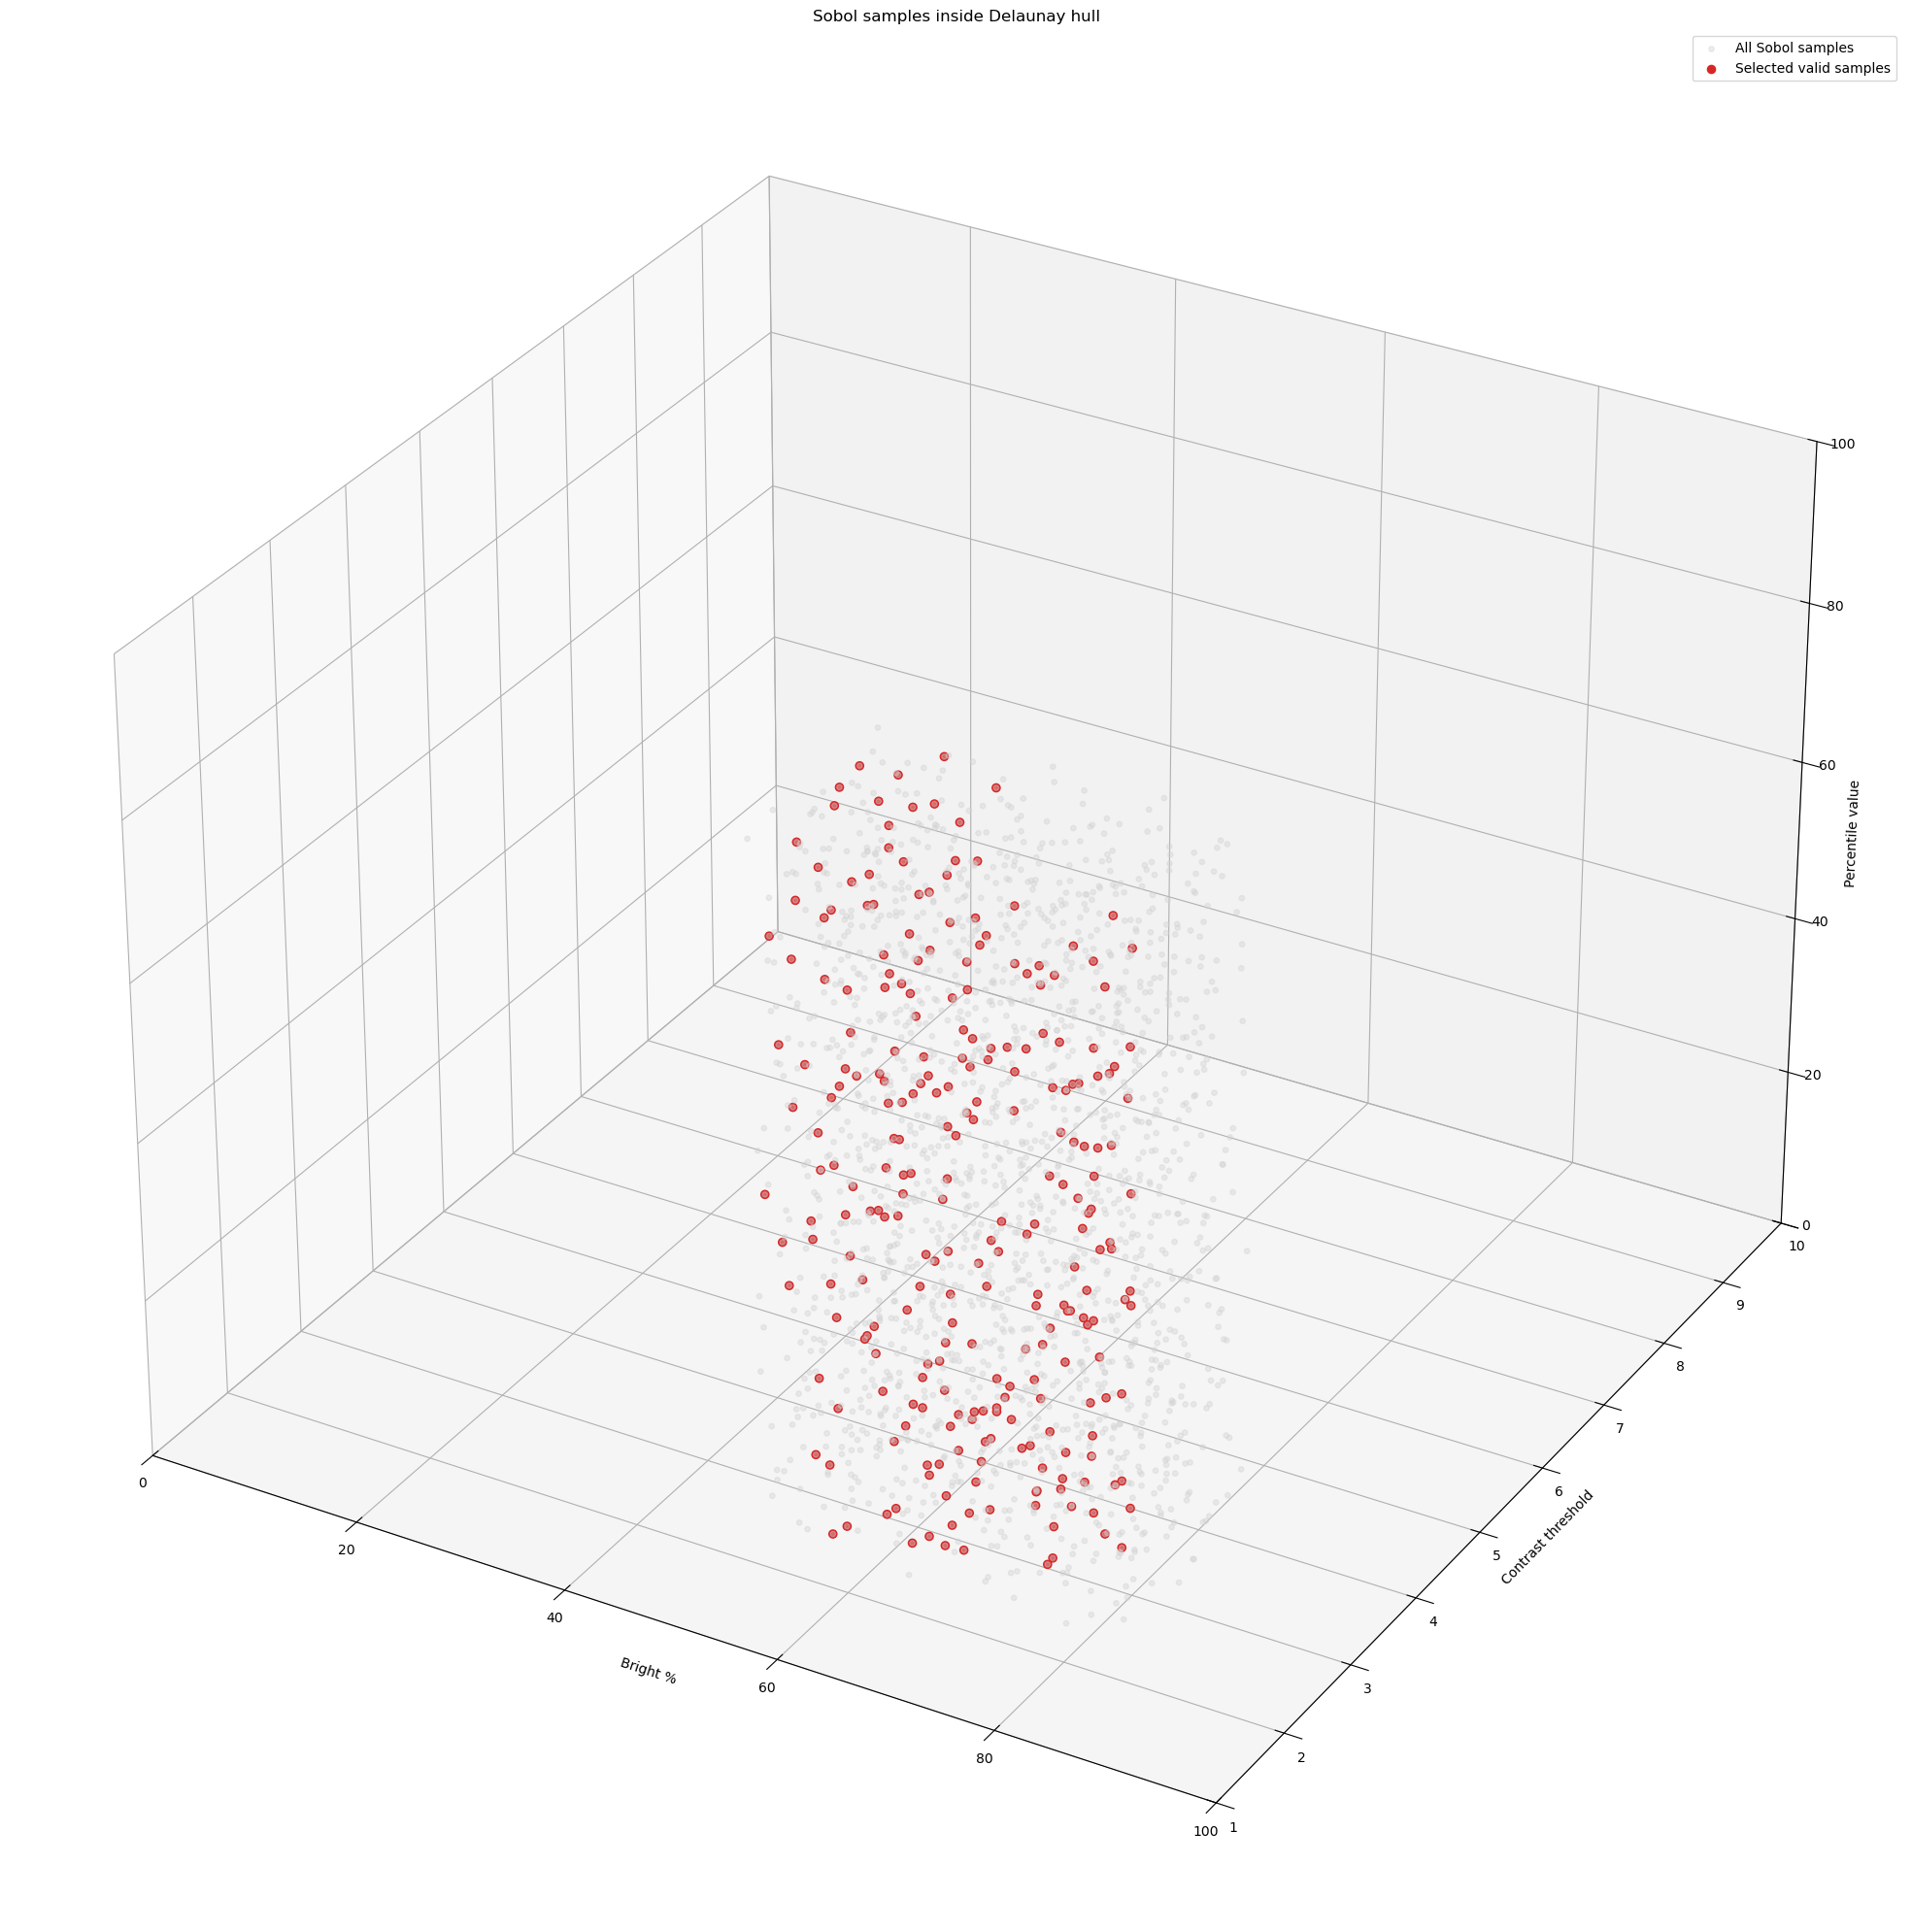

In [30]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(200, 20))
ax = fig.add_subplot(111, projection='3d')

# Plot ALL generated Sobol samples (in gray, semi-transparent)
ax.scatter(
    scaled_samples[:, 0],
    scaled_samples[:, 1],
    scaled_samples[:, 2],
    s=15, c='lightgray', alpha=0.4, label='All Sobol samples'
)

# Plot ONLY the valid ones (in color)
ax.scatter(
    valid_param_samples[:, 0],
    valid_param_samples[:, 1],
    valid_param_samples[:, 2],
    s=35, c='tab:red', alpha=1, label='Selected valid samples'
)


ax.set_xlim([0, 100])
ax.set_ylim([1, 10])
ax.set_zlim([0,100])
ax.set_xlabel("Bright %")
ax.set_ylabel("Contrast threshold")
ax.set_zlabel("Percentile value")
ax.set_title("Sobol samples inside Delaunay hull")

ax.legend()
plt.tight_layout()
plt.show()